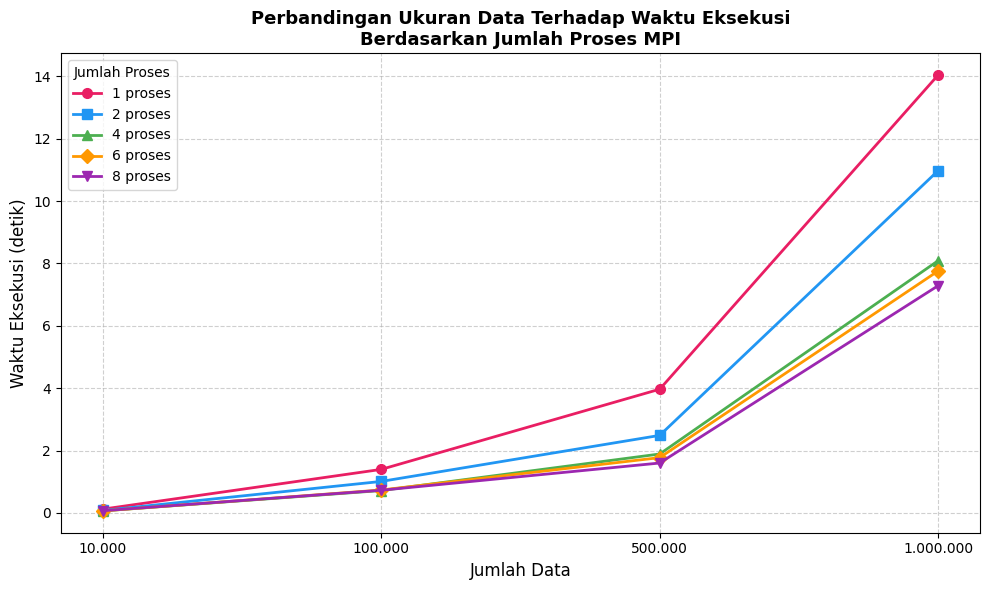

Grafik tersimpan: grafik_data_vs_waktu_equalspaced.png


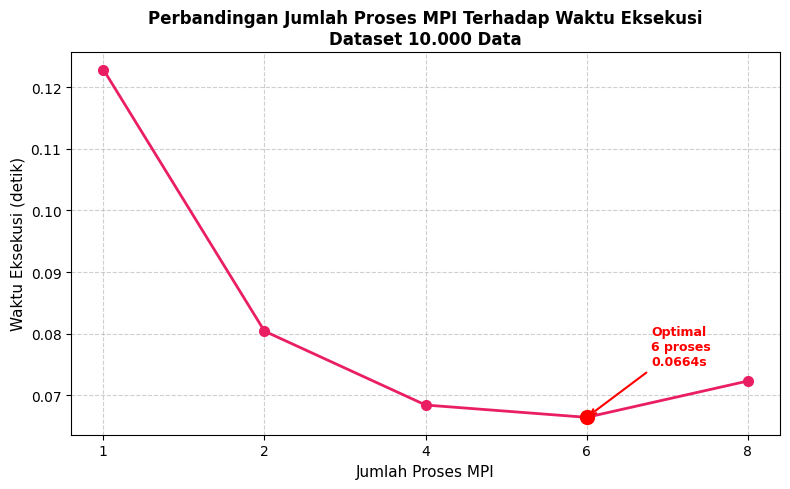

Grafik 10.000 tersimpan


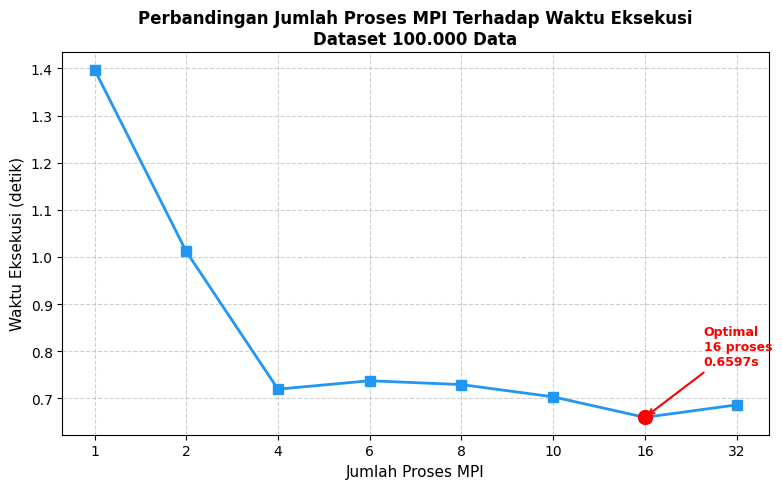

Grafik 100.000 tersimpan


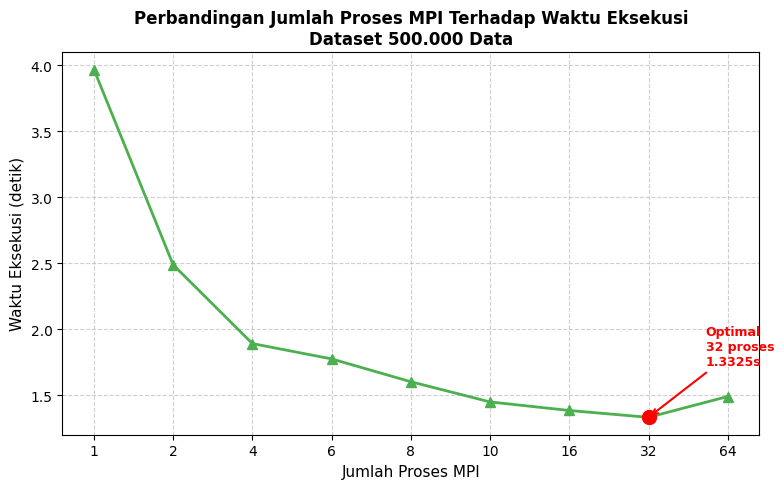

Grafik 500.000 tersimpan


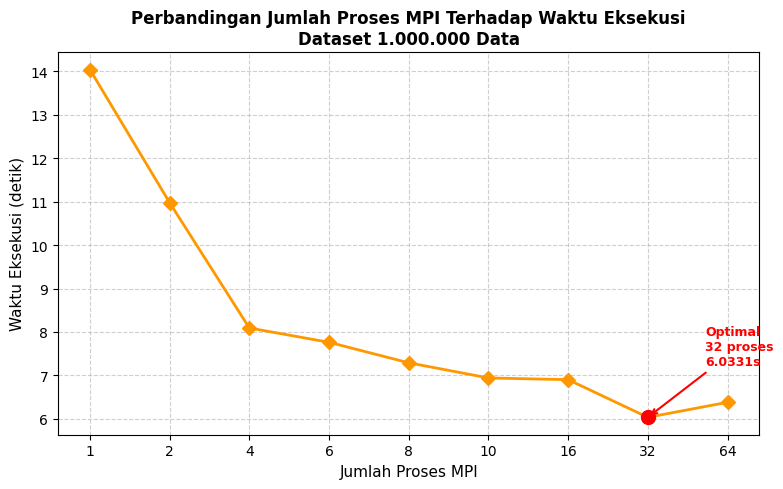

Grafik 1.000.000 tersimpan


In [1]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ===============================
# KONFIGURASI STYLE (konsisten dengan kode utama)
# ===============================

colors  = ['#E91E63', '#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
markers = ['o', 's', '^', 'D', 'v']

ukuran_label_map = {
    '10.000'   : (colors[0], markers[0]),
    '100.000'  : (colors[1], markers[1]),
    '500.000'  : (colors[2], markers[2]),
    '1.000.000': (colors[3], markers[3]),
}

# ===============================
# DATA LENGKAP
# ===============================

data_lengkap = {
    '10.000': {
        'proses': [1, 2, 4, 6, 8],
        'waktu' : [0.1229, 0.0804, 0.0684, 0.0664, 0.0723]
    },
    '100.000': {
        'proses': [1, 2, 4, 6, 8, 10, 16, 32, 64],
        'waktu' : [1.3977, 1.0117, 0.7195, 0.7373, 0.7292, 0.7032, 0.6597, 0.6861, 0.7356]
    },
    '500.000': {
        'proses': [1, 2, 4, 6, 8, 10, 16, 32, 64],
        'waktu' : [3.9688, 2.4882, 1.8915, 1.7753, 1.6022, 1.4493, 1.3843, 1.3325, 1.4904]
    },
    '1.000.000': {
        'proses': [1, 2, 4, 6, 8, 10, 16, 32, 64],
        'waktu' : [14.0442, 10.9784, 8.0910, 7.7613, 7.2893, 6.9400, 6.9005, 6.0331, 6.3794]
    }
}

# ===============================
# GRAFIK — Ukuran Data vs Waktu Eksekusi
# Sumbu X: equally spaced (bukan log)
# ===============================

ukuran_data  = [10000, 100000, 500000, 1000000]
ukuran_label = ['10.000', '100.000', '500.000', '1.000.000']
proses_list  = [1, 2, 4, 6, 8]

waktu_per_proses = {
    1: [0.1229, 1.3977, 3.9688, 14.0442],
    2: [0.0804, 1.0117, 2.4882, 10.9784],
    4: [0.0684, 0.7195, 1.8915,  8.0910],
    6: [0.0664, 0.7373, 1.7753,  7.7613],
    8: [0.0723, 0.7292, 1.6022,  7.2893]
}

x_pos = list(range(len(ukuran_data)))          # [0, 1, 2, 3] — jarak sama

fig, ax = plt.subplots(figsize=(10, 6))

for i, p in enumerate(proses_list):
    ax.plot(x_pos, waktu_per_proses[p],
            color=colors[i], marker=markers[i],
            linewidth=2, markersize=7,
            label=f'{p} proses')

ax.set_xticks(x_pos)
ax.set_xticklabels(ukuran_label)               # label tetap terbaca, jarak sama
ax.set_xlabel('Jumlah Data', fontsize=12)
ax.set_ylabel('Waktu Eksekusi (detik)', fontsize=12)
ax.set_title(
    'Perbandingan Ukuran Data Terhadap Waktu Eksekusi\nBerdasarkan Jumlah Proses MPI',
    fontsize=13, fontweight='bold'
)
ax.legend(title='Jumlah Proses', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('grafik_data_vs_waktu_equalspaced.png', dpi=150)
plt.show()
print('Grafik tersimpan: grafik_data_vs_waktu_equalspaced.png')


# ===============================
# GRAFIK PER UKURAN DATA — Proses vs Waktu + titik optimal
# (style & format judul sama dengan kode utama)
# ===============================

for label, d in data_lengkap.items():
    semua_proses = d['proses']
    semua_waktu  = d['waktu']
    warna, marker = ukuran_label_map[label]

    min_idx = semua_waktu.index(min(semua_waktu))
    opt_x   = semua_proses[min_idx]
    opt_y   = semua_waktu[min_idx]

    if min_idx + 1 < len(semua_proses):
        batas = semua_proses[min_idx + 1]
    else:
        batas = semua_proses[-1]
    batas = max(8, batas)

    tampil_proses = [p for p in semua_proses if p <= batas]
    tampil_waktu  = semua_waktu[:len(tampil_proses)]

    # Sumbu X equally spaced
    x_eq  = list(range(len(tampil_proses)))

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_eq, tampil_waktu,
            color=warna, marker=marker,
            linewidth=2, markersize=7)

    # Titik optimal (posisi di x_eq)
    opt_idx_eq = tampil_proses.index(opt_x)
    ax.scatter([opt_idx_eq], [opt_y], color='red', zorder=5, s=100)
    ax.annotate(
        f'Optimal\n{opt_x} proses\n{opt_y:.4f}s',
        xy=(opt_idx_eq, opt_y),
        xytext=(opt_idx_eq + len(x_eq) * 0.08,
                opt_y + (max(tampil_waktu) - min(tampil_waktu)) * 0.15),
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
        fontsize=9, color='red', fontweight='bold'
    )

    ax.set_xticks(x_eq)
    ax.set_xticklabels([str(p) for p in tampil_proses])   # label angka asli, jarak sama
    ax.set_title(
        f'Perbandingan Jumlah Proses MPI Terhadap Waktu Eksekusi\nDataset {label} Data',
        fontsize=12, fontweight='bold'
    )
    ax.set_xlabel('Jumlah Proses MPI', fontsize=11)
    ax.set_ylabel('Waktu Eksekusi (detik)', fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(f'grafik_optimal_{label}_equalspaced.png', dpi=150)
    plt.show()
    print(f'Grafik {label} tersimpan')
